['filename', 'width', 'height', 'class', 'xmin', 'ymin', 'xmax', 'ymax']
                                            filename  width  height  \
0  c--188-_jpg.rf.df8c04f880e507f44d63d74b701f381...    563     537   
1  c--188-_jpg.rf.df8c04f880e507f44d63d74b701f381...    563     537   
2  c--188-_jpg.rf.df8c04f880e507f44d63d74b701f381...    563     537   
3  c--188-_jpg.rf.df8c04f880e507f44d63d74b701f381...    563     537   
4  f--28-_jpg.rf.de4fc5ebba3bbc0baea64e669225c7c5...    563     537   

          class  xmin  ymin  xmax  ymax  
0  Microplastic   271    15   305    46  
1  Microplastic   348   265   402   308  
2  Microplastic   146   279   181   317  
3  Microplastic   477   302   542   367  
4  Microplastic   279   137   337   205  
      filename  width  height  class   xmin   ymin   xmax   ymax
0        False  False   False  False  False  False  False  False
1        False  False   False  False  False  False  False  False
2        False  False   False  False  False  False  F

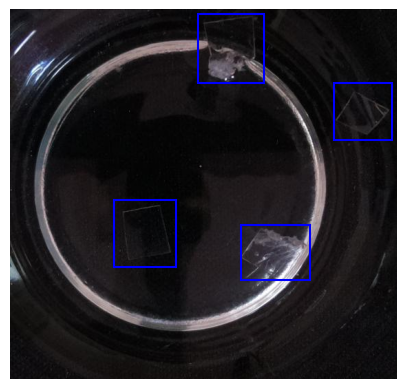

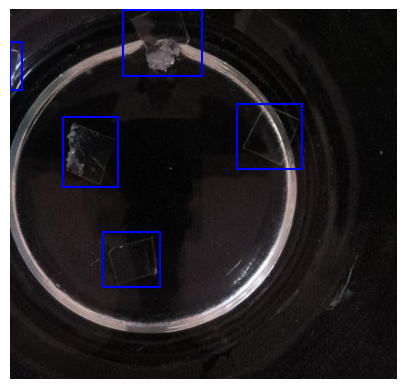

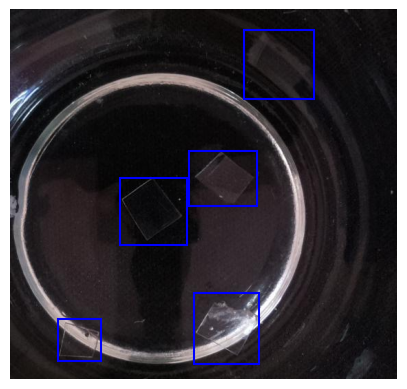

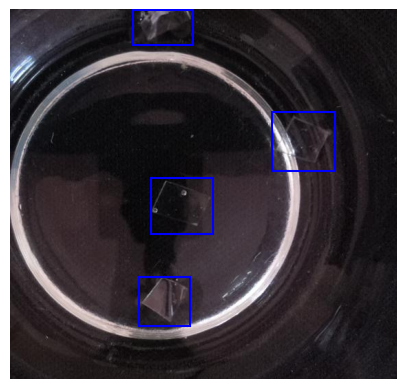

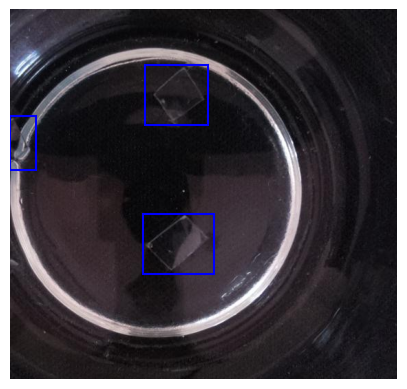

Split 781 images -> train:546 valid:156 test:79


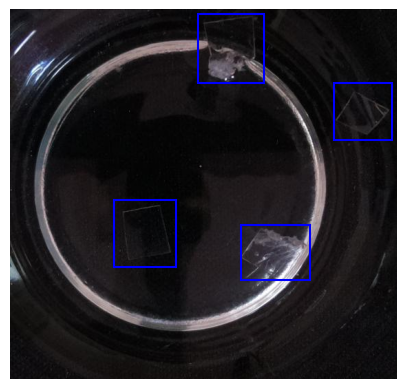

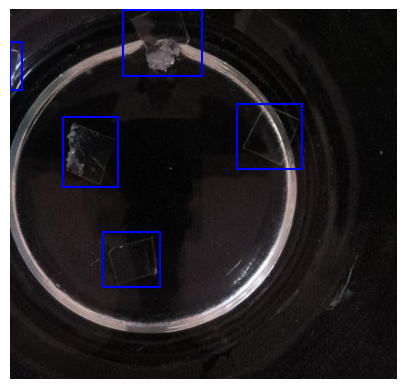

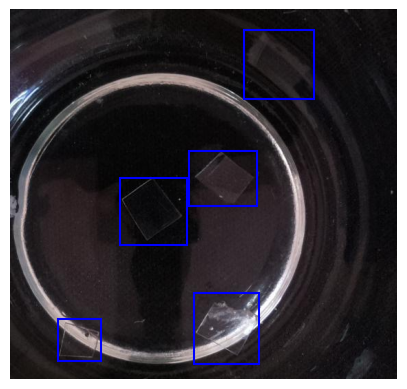

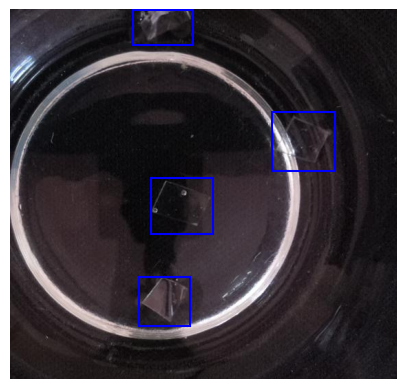

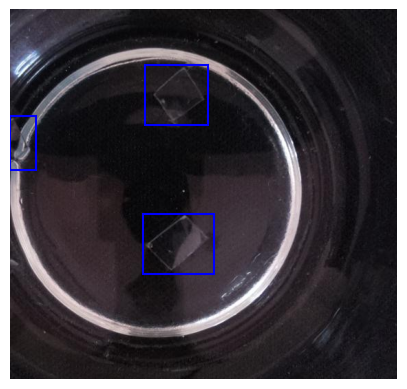

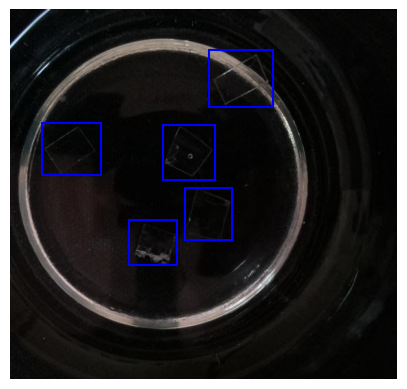

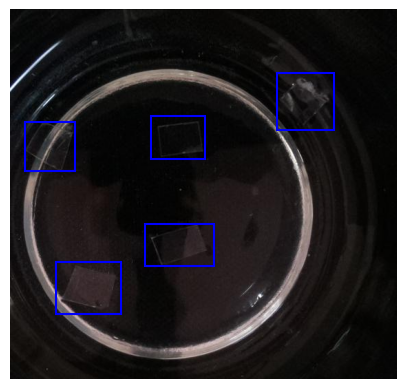

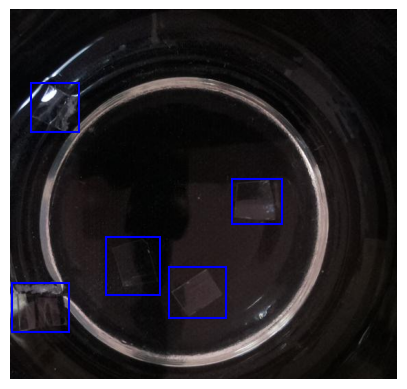

In [6]:
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

sys.path.append("../src")

CSV_PATH = "../data/microplastic-dataset-for-computer-vision/_annotations.csv"
IMAGES_DIR = "../data/microplastic-dataset-for-computer-vision"

df = pd.read_csv(CSV_PATH)
print(df.columns.tolist())
print(df.head())
print(df.isna())
print(df[df.duplicated()])

from data_loader import convert_csv_to_yolo, draw_boxes, split_dataset

class_names = convert_csv_to_yolo(
    csv_path="../data/microplastic-dataset-for-computer-vision/_annotations.csv",
    images_dir="../data/microplastic-dataset-for-computer-vision",
    labels_out_dir="../data/microplastic-dataset-for-computer-vision/labels"
)

# sanity check a few images
import os
label_dir = "../data/microplastic-dataset-for-computer-vision/labels"
sample_images = [f for f in os.listdir("../data/microplastic-dataset-for-computer-vision") if f.endswith(".jpg")]
labelled_images = [f for f in sample_images if os.path.exists(os.path.join(label_dir, f.replace('.jpg', '.txt')))]
for img_name in labelled_images[:5]:
    img_path = f"../data/microplastic-dataset-for-computer-vision/{img_name}"
    label_path = f"{label_dir}/{img_name.replace('.jpg', '.txt')}"
    draw_boxes(img_path, label_path)

split_dataset(
    images_dir="../data/microplastic-dataset-for-computer-vision",
    labels_dir="../data/microplastic-dataset-for-computer-vision/labels",
    output_dir="../data/microplastic-dataset-for-computer-vision"
)

import os
from data_loader import draw_boxes

base_dir = "../data/microplastic-dataset-for-computer-vision"
label_dir = os.path.join(base_dir, "labels")
sample_images = [f for f in os.listdir(base_dir) if f.endswith(".jpg")]
labelled_images = [f for f in sample_images if os.path.exists(os.path.join(label_dir, f.replace('.jpg', '.txt')))]

for img_name in labelled_images[:8]:
    img_path = os.path.join(base_dir, img_name)
    label_path = os.path.join(label_dir, img_name.replace(".jpg", ".txt"))
    draw_boxes(img_path, label_path)


In [12]:
import sys
import importlib
from pathlib import Path

notebook_dir = Path.cwd()
for candidate in [notebook_dir] + list(notebook_dir.parents):
    src_dir = candidate / "src"
    if src_dir.exists():
        sys.path.insert(0, str(src_dir.resolve()))
        repo_root = candidate
        break
else:
    raise FileNotFoundError("Could not locate the src directory from notebook runtime path")

import train
importlib.reload(train)

train.run_quick_test(
    data_yaml=str((repo_root / "data.yaml").resolve()),
    model_path=str((repo_root / "yolov8n.pt").resolve()),
)


Ultralytics 8.4.103  Python-3.13.7 torch-2.13.0+cpu CPU (AMD Ryzen 5 7535HS with Radeon Graphics)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\anyas\AppData\Local\Temp\tmpm7f5d1lx.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=C:\Users\anyas\Triple-T\yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=quick_test-15, nbs=64, nms

KeyboardInterrupt: 